# Projeto de Classificação de Imagens na RPi com Treino no Edge Impulse
> Adaptado da seção [*Image Classification Fundamentals*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/raspi/image_classification/image_classification_fund.html) do [Prof. Marcelo Rovai](https://github.com/Mjrovai) no livro [*EdgeML Made Easy*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/) e do repositório do GitHub [Edge Machine Learning Systems Engineering](https://github.com/Mjrovai/UNIFEI-IESTI05-EDGE_AI/tree/main).

## Importar bibliotecas necessárias
```python

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tflite_runtime.interpreter as tflite

## Modelos a serem testados

In [2]:
!ls ./models

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
cifar10.tflite			   tensorflow-lite-float32-model.3.lite
labels.txt			   tensorflow-lite-int8-quantized-model.3.lite
mobilenet_v2_1.0_224_quant.tflite


## Conjunto de dados de teste

In [3]:
!ls ./dataset

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
background  falcon  grogu


In [4]:
!ls ./dataset/background

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
image_20251028-111646.jpg  image_20251028-111700.jpg  image_20251028-111722.jpg
image_20251028-111647.jpg  image_20251028-111701.jpg  image_20251028-111723.jpg
image_20251028-111648.jpg  image_20251028-111702.jpg  image_20251028-111724.jpg
image_20251028-111649.jpg  image_20251028-111703.jpg  image_20251028-111725.jpg
image_20251028-111650.jpg  image_20251028-111704.jpg  image_20251028-111726.jpg
image_20251028-111651.jpg  image_20251028-111705.jpg  image_20251028-111727.jpg
image_20251028-111652.jpg  image_20251028-111706.jpg  image_20251028-111728.jpg
image_20251028-111653.jpg  image_20251028-111715.jpg  image_20251028-111729.jpg
image_20251028-111654.jpg  image_20251028-111716.jpg  image_20251028-111730.jpg
image_20251028-111655.jpg  image_20251028-111717.jpg  image_20251028-111731.jpg
image_20251028-111656.jpg  image_20251028-111718.jpg  image_20251028-111732.jpg
image_20251028-111657.jpg  image_20251028-1117

In [5]:
!ls ./dataset/grogu

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
image_20251028-111453.jpg  image_20251028-111511.jpg  image_20251028-111531.jpg
image_20251028-111454.jpg  image_20251028-111512.jpg  image_20251028-111532.jpg
image_20251028-111455.jpg  image_20251028-111513.jpg  image_20251028-111533.jpg
image_20251028-111456.jpg  image_20251028-111517.jpg  image_20251028-111534.jpg
image_20251028-111457.jpg  image_20251028-111518.jpg  image_20251028-111535.jpg
image_20251028-111458.jpg  image_20251028-111519.jpg  image_20251028-111536.jpg
image_20251028-111459.jpg  image_20251028-111520.jpg  image_20251028-111541.jpg
image_20251028-111504.jpg  image_20251028-111521.jpg  image_20251028-111542.jpg
image_20251028-111505.jpg  image_20251028-111522.jpg  image_20251028-111543.jpg
image_20251028-111506.jpg  image_20251028-111523.jpg  image_20251028-111544.jpg
image_20251028-111507.jpg  image_20251028-111524.jpg  image_20251028-111545.jpg
image_20251028-111508.jpg  image_20251028-1115

In [6]:
!ls ./dataset/falcon

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (pt_BR.UTF-8)
image_20251028-110830.jpg  image_20251028-110951.jpg  image_20251028-111032.jpg
image_20251028-110833.jpg  image_20251028-110952.jpg  image_20251028-111033.jpg
image_20251028-110838.jpg  image_20251028-110953.jpg  image_20251028-111034.jpg
image_20251028-110842.jpg  image_20251028-110954.jpg  image_20251028-111035.jpg
image_20251028-110858.jpg  image_20251028-111003.jpg  image_20251028-111036.jpg
image_20251028-110905.jpg  image_20251028-111004.jpg  image_20251028-111039.jpg
image_20251028-110915.jpg  image_20251028-111005.jpg  image_20251028-111040.jpg
image_20251028-110924.jpg  image_20251028-111007.jpg  image_20251028-111041.jpg
image_20251028-110925.jpg  image_20251028-111012.jpg  image_20251028-111042.jpg
image_20251028-110926.jpg  image_20251028-111013.jpg  image_20251028-111043.jpg
image_20251028-110927.jpg  image_20251028-111014.jpg  image_20251028-111044.jpg
image_20251028-110929.jpg  image_20251028-1110

## Inspecionar o modelo

In [7]:
labels = ['background', 'falcon', 'grogu']

In [8]:
img_path = "./dataset/grogu/image_20251028-111458.jpg"
model_path = "./models/tensorflow-lite-int8-quantized-model.3.lite"

In [9]:
    # Carregar o modelo TFLite
    interpreter = tflite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Obter os tensores de entrada e saída
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

In [10]:
input_details

[{'name': 'serving_default_x:0',
  'index': 0,
  'shape': array([  1, 160, 160,   3]),
  'shape_signature': array([  1, 160, 160,   3]),
  'dtype': numpy.int8,
  'quantization': (0.003921568859368563, -128),
  'quantization_parameters': {'scales': array([0.00392157], dtype=float32),
   'zero_points': array([-128]),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [11]:
 output_details

[{'name': 'StatefulPartitionedCall:0',
  'index': 180,
  'shape': array([1, 3]),
  'shape_signature': array([1, 3]),
  'dtype': numpy.int8,
  'quantization': (0.00390625, -128),
  'quantization_parameters': {'scales': array([0.00390625], dtype=float32),
   'zero_points': array([-128]),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [12]:
# Obter os tipos de dados dos tensores de entrada
input_dtype = input_details[0]['dtype']
input_dtype

numpy.int8

Agora, o modelo espera um tipo de dados “int8”, o que significa que devemos adaptar a imagem de entrada:

/home/pi/.local/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/pi/.local/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


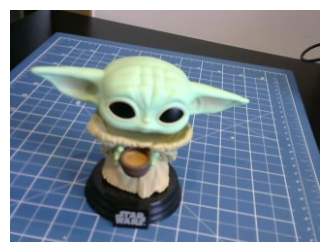

In [13]:
img = Image.open(img_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

## Pre-Processing

In [14]:
scale, zero_point = input_details[0]['quantization']
img = img.resize((input_details[0]['shape'][1], 
                  input_details[0]['shape'][2]))
img_array = np.array(img, dtype=np.float32) / 255.0
img_array = (img_array / scale + zero_point).clip(-128, 127).astype(np.int8)
input_data = np.expand_dims(img_array, axis=0)
input_data.shape, input_data.dtype

((1, 160, 160, 3), dtype('int8'))

## Inference

In [15]:
# Inferência no RPi
start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
end_time = time.time()
inference_time = (end_time - start_time) * 1000  # Convert to milliseconds
print ("Inference time: {:.1f}ms".format(inference_time))

Inference time: 75.8ms


In [16]:
# Obter resultados e mapeá-los para as classes
predictions = interpreter.get_tensor(output_details[0]['index'])[0]
predictions

array([-116, -116,  104], dtype=int8)

In [17]:
# Obter os índices dos k melhores resultados
top_k_results=3
top_k_indices = np.argsort(predictions)[::-1][:top_k_results]
top_k_indices

array([2, 1, 0], dtype=int32)

In [18]:
#Obter parâmetros de quantização
scale, zero_point = output_details[0]['quantization']

# Desquantizar a saída
dequantized_output = (predictions.astype(np.float32) - zero_point) * scale
dequantized_output

array([0.046875, 0.046875, 0.90625 ], dtype=float32)

O modelo já possui um softmax em sua saída e, portanto, podemos usar sua saída bruta como as "probabilidades".

In [19]:
# exp_output = np.exp(dequantized_output - np.max(dequantized_output))
# probabilities = exp_output / np.sum(exp_output)
probabilities = dequantized_output

print("\n\t[PREDICTION]        [Prob]\n")
for i in range(top_k_results):
    print("\t{:20}: {:.2f}%".format(
        labels[top_k_indices[i]],
        probabilities[top_k_indices[i]] * 100))

Vamos usar um modelo não quantizado

In [20]:
img_path = "./dataset/grogu/image_20251028-111458.jpg"
model_path = "./models/tensorflow-lite-float32-model.3.lite"


In [21]:
    # Carregar o modelo TFLite
    interpreter = tflite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Obter os tensores de entrada e saída
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

In [22]:
input_details

[{'name': 'serving_default_x:0',
  'index': 0,
  'shape': array([  1, 160, 160,   3]),
  'shape_signature': array([  1, 160, 160,   3]),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [23]:
output_details

[{'name': 'StatefulPartitionedCall:0',
  'index': 180,
  'shape': array([1, 3]),
  'shape_signature': array([1, 3]),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

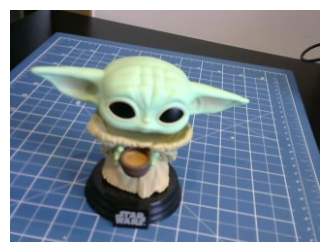

In [24]:
img = Image.open(img_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [25]:
# Obter os tipos de dados dos tensores de entrada
input_dtype = input_details[0]['dtype']
input_dtype

numpy.float32

Agora o modelo espera uma entrada como float32, então, vamos normalizar os dados para [0,1].

In [26]:
img = img.resize((input_details[0]['shape'][1], 
                  input_details[0]['shape'][2]))
img_array = np.array(img, dtype=np.float32) / 255.0
input_data = np.expand_dims(img_array, axis=0)
input_data.shape, input_data.dtype

((1, 160, 160, 3), dtype('float32'))

In [27]:
# Inferência no RPi
#input_data = input_data.astype(input_details[0]['dtype'])
start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
end_time = time.time()
inference_time = (end_time - start_time) * 1000  # Converter para milissegundos
print ("Inference time: {:.1f}ms".format(inference_time))

Inference time: 86.5ms


In [28]:
# Obter os resultados e mapeá-los para as classes
predictions = interpreter.get_tensor(output_details[0]['index'])[0]

In [29]:
predictions

array([0.00519298, 0.00993527, 0.9848718 ], dtype=float32)

In [30]:
# Obter os índices dos k melhores resultados
top_k_results=3
top_k_indices = np.argsort(predictions)[::-1][:top_k_results]

In [31]:
top_k_indices

array([2, 1, 0], dtype=int32)

In [32]:
print("\n\t[PREDICTION]        [Prob]\n")
for i in range(top_k_results):
    print("\t{:20}: {}%".format(
        labels[top_k_indices[i]],
            (int(predictions[top_k_indices[i]]*100))))


	[PREDICTION]        [Prob]

	grogu               : 98%
	falcon              : 0%
	background          : 0%


### Função para lidar com qualquer tipo de modelo 

In [33]:
def image_classification(img_path, model_path, labels, top_k_results=3, apply_softmax=False):
    # Carregar a imagem
    img = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

    # Carregar o modelo TFLite
    interpreter = tflite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # Obter os tensores de entrada e saída
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Pré-processamento
    img = img.resize((input_details[0]['shape'][1], 
                      input_details[0]['shape'][2]))
    
    input_dtype = input_details[0]['dtype']
    
    # Adaptar a imagem conforme o tipo de entrada esperado pelo modelo
    if input_dtype == np.uint8:
        input_data = np.expand_dims(np.array(img), axis=0)
    elif input_dtype == np.int8:
        scale, zero_point = input_details[0]['quantization']
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_array = (img_array / scale + zero_point).clip(-128, 127).astype(np.int8)
        input_data = np.expand_dims(img_array, axis=0)
    else:  # float32
        input_data = np.expand_dims(np.array(img, dtype=np.float32), axis=0) / 255.0

    # Inferência no RPi
    start_time = time.time()
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    end_time = time.time()
    inference_time = (end_time - start_time) * 1000  # Converter para milissegundos

    # Obter os resultados da predição
    predictions = interpreter.get_tensor(output_details[0]['index'])[0]

    # Obter os índices dos k melhores resultados
    top_k_indices = np.argsort(predictions)[::-1][:top_k_results]

    # Lidar com a saída conforme o tipo de dado
    output_dtype = output_details[0]['dtype']
    if output_dtype in [np.int8, np.uint8]:
        # Desquantizar a saída
        scale, zero_point = output_details[0]['quantization']
        predictions = (predictions.astype(np.float32) - zero_point) * scale
    
    if apply_softmax:
        # Aplicar softmax para obter probabilidades
        exp_preds = np.exp(predictions - np.max(predictions))
        probabilities = exp_preds / np.sum(exp_preds)
    else:
        probabilities = predictions

    print("\n\t[PREDICTION]        [Prob]\n")
    for i in range(top_k_results):
        print("\t{:20}: {:.1f}%".format(
            labels[top_k_indices[i]],
            probabilities[top_k_indices[i]] * 100))
    print ("\n\tInference time: {:.1f}ms".format(inference_time))

# Exemplo de uso:
# image_classification('caminho_para_imagem.jpg', 'caminho_para_modelo.tflite', labels)


	[PREDICTION]        [Prob]

	grogu               : 90.6%
	falcon              : 4.7%
	background          : 4.7%

	Inference time: 55.1ms


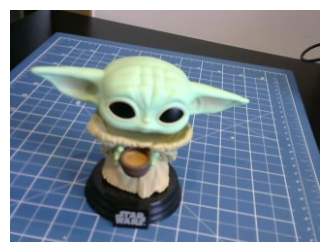

In [34]:
img_path = "./dataset/grogu/image_20251028-111458.jpg"
model_path = "./models/tensorflow-lite-int8-quantized-model.3.lite"

labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	grogu               : 98.5%
	falcon              : 1.0%
	background          : 0.5%

	Inference time: 54.5ms


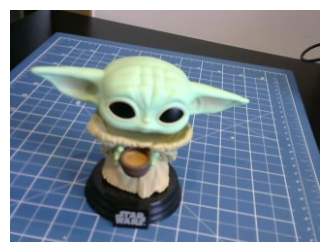

In [35]:
img_path = "./dataset/grogu/image_20251028-111458.jpg"
model_path = "./models/tensorflow-lite-float32-model.3.lite"
labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	falcon              : 86.7%
	background          : 11.7%
	grogu               : 1.6%

	Inference time: 55.1ms


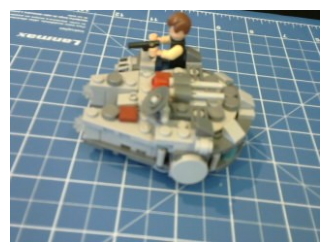

In [36]:
img_path = "./dataset/falcon/image_20251028-110954.jpg"
model_path = "./models/tensorflow-lite-int8-quantized-model.3.lite"
labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	falcon              : 91.5%
	background          : 5.5%
	grogu               : 3.0%

	Inference time: 54.4ms


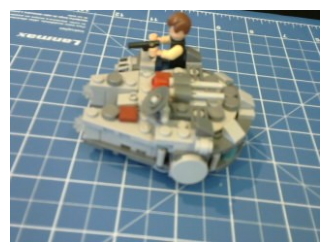

In [37]:
img_path = "./dataset/falcon/image_20251028-110954.jpg"
model_path = "./models/tensorflow-lite-float32-model.3.lite"
labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	background          : 99.2%
	grogu               : 0.4%
	falcon              : 0.4%

	Inference time: 54.9ms


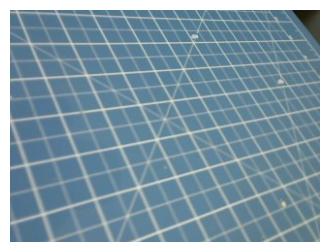

In [38]:
img_path = "./dataset/background/image_20251028-111651.jpg"
model_path = "./models/tensorflow-lite-int8-quantized-model.3.lite"
labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	background          : 99.3%
	grogu               : 0.4%
	falcon              : 0.3%

	Inference time: 54.5ms


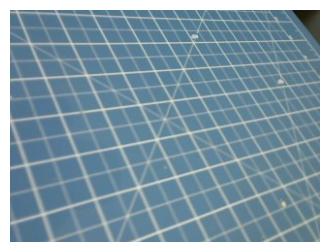

In [39]:
img_path = "./dataset/background/image_20251028-111651.jpg"
model_path = "./models/tensorflow-lite-float32-model.3.lite"
labels = ['background', 'falcon', 'grogu']
image_classification(img_path, model_path, labels, top_k_results=len(labels))

## Classificação de uma imagem capturada pela câmera RPi

In [40]:
from picamera2 import Picamera2

In [43]:
def capture_image(image_path):
 # 1. Inicializar a câmera
    picam2 = Picamera2()
    picam2.start()
    print("Câmera inicializada.")

    # O bloco 'finally' garante que a câmera será fechada, não importa o que aconteça.
    try:
        # Espera inicial para a câmera estabilizar
        time.sleep(2)

        print(f"Iniciando a captura")
        # 2. Capturar imagem
        picam2.capture_file(image_path)
        print(f"Imagem capturada: {image_path}")

    finally:
        # 3. ESTE CÓDIGO SEMPRE SERÁ EXECUTADO!
        print("Fechando a câmera...")
        picam2.stop()
        picam2.close()
        print("Câmera fechada com sucesso.")


[0:05:26.086745588] [966]  INFO Camera camera.cpp:1033 configuring streams: (0) 640x480-MJPEG


Câmera inicializada.
Iniciando a captura
Imagem capturada: ./imagens/cam_img_test_2.jpg
Fechando a câmera...
Câmera fechada com sucesso.

	[PREDICTION]        [Prob]

	grogu               : 67.2%
	falcon              : 32.4%
	background          : 0.0%

	Inference time: 55.2ms


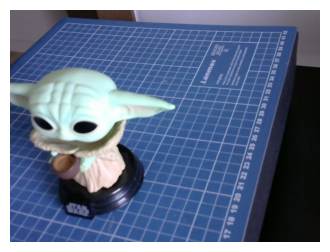

In [47]:
img_path = './imagens/cam_img_test_2.jpg'
model_path = "./models/tensorflow-lite-int8-quantized-model.3.lite"
labels = ['background', 'falcon', 'grogu']
capture_image(img_path)
image_classification(img_path, model_path, labels, top_k_results=len(labels))